# Image Enhancement Model: Training and Validation

This notebook trains and validates the lightweight ML regressor used by the browser worker. The model does not perform super-resolution. It predicts correction parameters for brightness, contrast, saturation, and gamma; the browser then applies those parameters asynchronously to image pixels.

## Dataset

The downloaded Unsplash dataset is a super-resolution dataset. Its original CSV pairs mainly differ by pixelation/resolution, while this project is about brightness, contrast, and colorfulness. Therefore, the notebook uses `ml/data/high res` as high-quality references and generates synthetic low-quality versions with reduced brightness, contrast, color, plus mild blur/noise/JPEG artifacts.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd()
if ROOT.name == 'ml':
    ROOT = ROOT.parent
sys.path.append(str(ROOT / 'ml'))

from train_parameter_model import (
    load_rgb,
    image_features,
    fit_target_params,
    paired_paths,
    train_mlp,
    predict_mlp,
    split_train_validation,
    parameter_metrics,
    export_weights,
)

DATASET = ROOT / 'ml' / 'data' / 'quality_pairs'
LOW_DIR = DATASET / 'low'
HIGH_DIR = DATASET / 'high'
WEIGHTS_OUT = ROOT / 'src' / 'modelWeights.js'
METRICS_OUT = ROOT / 'ml' / 'training_metrics.json'

print('Dataset:', DATASET)
print('Low images:', len(list(LOW_DIR.glob('*.jpg'))))
print('High images:', len(list(HIGH_DIR.glob('*.jpg'))))

Dataset: c:\Users\DELL\Desktop\MLprojects\ImageEnhancement\ml\data\quality_pairs
Low images: 1000
High images: 1000


If `quality_pairs` does not exist yet, run this command in the project terminal first:

```powershell
python ml\create_synthetic_pairs.py --source "ml\data\high res" --out ml\data\quality_pairs --variants 2 --limit 500 --max-side 512
```

In [2]:
features = []
targets = []
pairs = list(paired_paths(LOW_DIR, HIGH_DIR))[:2400]

for low_path, high_path in pairs:
    low = load_rgb(low_path)
    high = load_rgb(high_path)
    if low.shape != high.shape:
        high_image = Image.fromarray((high * 255).astype(np.uint8)).resize(low.shape[1::-1])
        high = np.asarray(high_image, dtype=np.float32) / 255.0
    features.append(image_features(low))
    targets.append(fit_target_params(low, high))

features = np.vstack(features)
targets = np.vstack(targets)
print('Pairs loaded:', len(features))
print('Feature shape:', features.shape)
print('Target shape:', targets.shape)

Pairs loaded: 1000
Feature shape: (1000, 5)
Target shape: (1000, 4)


In [3]:
train_x, train_y, val_x, val_y = split_train_validation(features, targets, validation_split=0.2, seed=42)
weights, history = train_mlp(train_x, train_y, epochs=4000, hidden=24)

train_pred = predict_mlp(train_x, weights)
val_pred = predict_mlp(val_x, weights)

metrics = {
    'pairs_total': int(len(features)),
    'pairs_train': int(len(train_x)),
    'pairs_validation': int(len(val_x)),
    'epochs': 4000,
    'hidden_units': 24,
    'history': history,
    'train': parameter_metrics(train_pred, train_y),
    'validation': parameter_metrics(val_pred, val_y),
}

export_weights(WEIGHTS_OUT, weights)
METRICS_OUT.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

print(json.dumps(metrics['validation'], indent=2))
print('Saved weights to:', WEIGHTS_OUT)
print('Saved metrics to:', METRICS_OUT)

{
  "brightness": {
    "mae": 3.670095205307007,
    "max_error": 10.699633598327637
  },
  "contrast": {
    "mae": 0.08415334671735764,
    "max_error": 0.320351243019104
  },
  "saturation": {
    "mae": 0.10097715258598328,
    "max_error": 0.29146790504455566
  },
  "gamma": {
    "mae": 0.007960665971040726,
    "max_error": 0.024951040744781494
  }
}
Saved weights to: c:\Users\DELL\Desktop\MLprojects\ImageEnhancement\src\modelWeights.js
Saved metrics to: c:\Users\DELL\Desktop\MLprojects\ImageEnhancement\ml\training_metrics.json


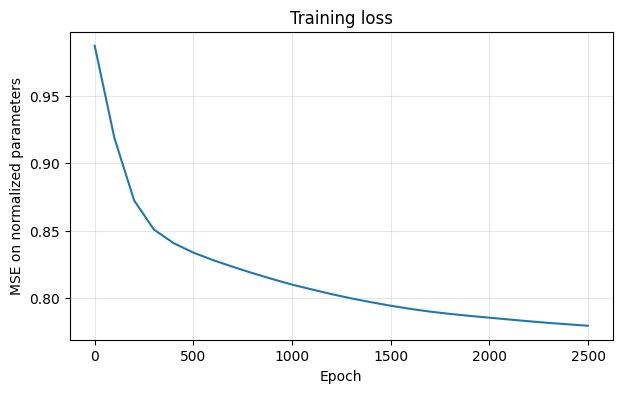

In [4]:
epochs = [item['epoch'] for item in history]
losses = [item['loss'] for item in history]

plt.figure(figsize=(7, 4))
plt.plot(epochs, losses)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('MSE on normalized parameters')
plt.grid(True, alpha=0.3)
plt.show()

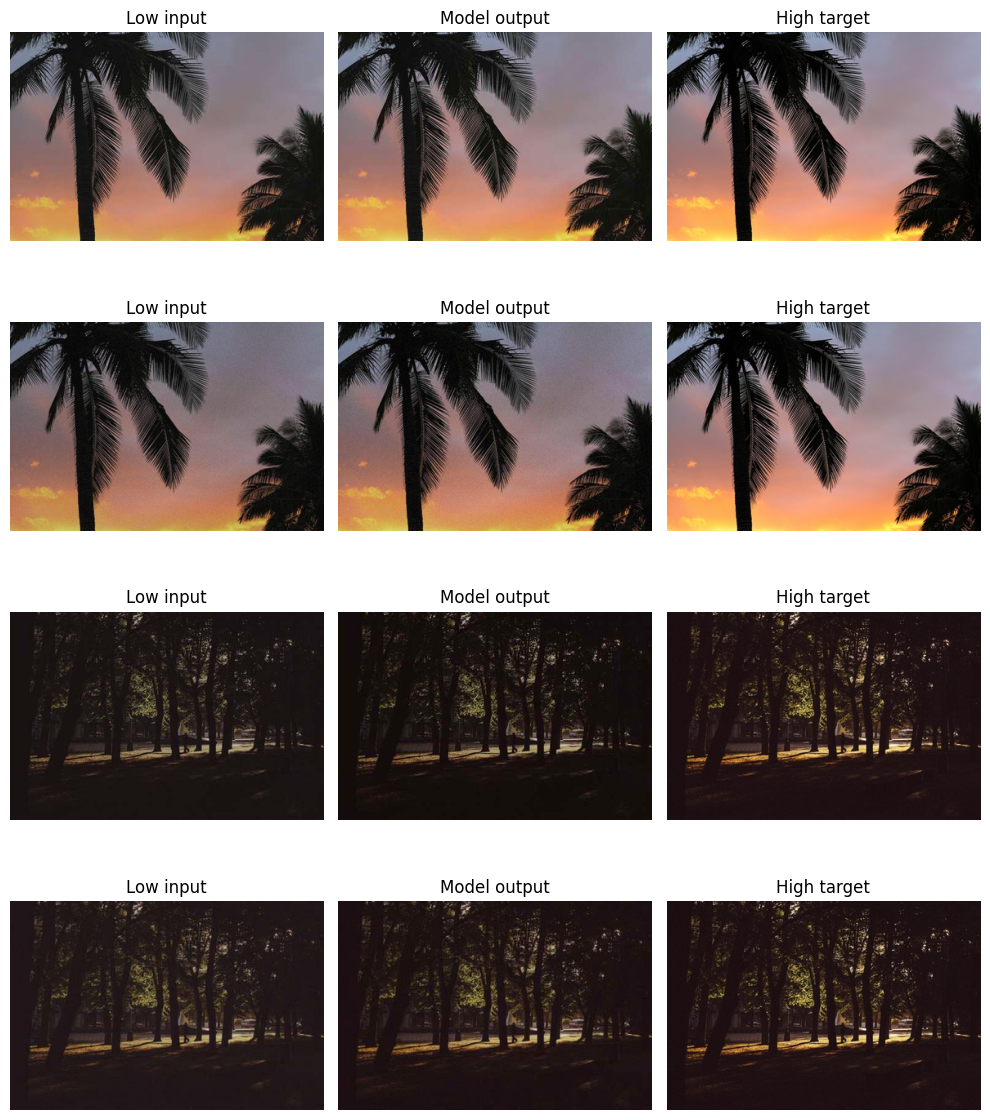

In [5]:
def clamp(value, low, high):
    return np.minimum(high, np.maximum(low, value))

def apply_predicted_params(rgb, params):
    brightness = np.clip(params[0], -22, 30)
    contrast = np.clip(1 + (params[1] - 1) * 0.52, 0.92, 1.18)
    saturation = np.clip(1 + (params[2] - 1) * 0.34, 0.95, 1.12)
    gamma = np.clip(1 + (params[3] - 1) * 0.9, 0.9, 1.1)

    result = np.power(np.clip(rgb, 0, 1), gamma)
    result = (result - 0.5) * contrast + 0.5
    result = result + brightness / 255.0
    gray = 0.2126 * result[..., 0] + 0.7152 * result[..., 1] + 0.0722 * result[..., 2]
    result = gray[..., None] + (result - gray[..., None]) * saturation
    return clamp(result, 0, 1)

sample_pairs = pairs[-4:]
fig, axes = plt.subplots(len(sample_pairs), 3, figsize=(10, 12))

for row, (low_path, high_path) in enumerate(sample_pairs):
    low = load_rgb(low_path, size=384)
    high = load_rgb(high_path, size=384)
    pred_params = predict_mlp(np.array([image_features(low)]), weights)[0]
    enhanced = apply_predicted_params(low, pred_params)

    for col, (title, image) in enumerate([('Low input', low), ('Model output', enhanced), ('High target', high)]):
        axes[row, col].imshow(image)
        axes[row, col].set_title(title)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()